# [Buy Smart or Cry Later: интеллектуальная система оценки автомобилей с контролем рисков]


1. Вид и тип задачи

Это задача регрессии: необходимо предсказывать численное значение стоимости автомобиля — price_rub.

Тип задачи — обучение с учителем:
у нас есть исторические данные по автомобилям (характеристики, регион, состояние и др.) и известная фактическая цена для каждого объекта.

2. Целевая переменная и признаки
Целевая переменная (таргет):

price_rub — фактическая рыночная стоимость автомобиля в рублях.

3. Признаки (фичи), доступные модели:
Технические характеристики:

engine_cc — объём двигателя

mileage_kmpl — расход топлива

make_year — год выпуска

owner_count — количество владельцев

accidents_reported — количество зафиксированных ДТП

Категориальные признаки:

brand — марка автомобиля

fuel_type — тип топлива

transmission — тип коробки передач

color — цвет

service_history — история обслуживания

insurance_valid — наличие действующей страховки

region — макро-регион продажи

4. Критерии успешности проекта
С точки зрения бизнеса:

Модель должна снизить среднюю ошибку оценки по сравнению с baseline-моделью (линейная регрессия).

Важно минимизировать:

риск переплаты при выкупе автомобиля (Overpricing),

риск недополученной прибыли при заниженной оценке (Underpricing).

Модель должна быть прозрачной и объяснимой (SHAP-анализ), чтобы бизнес доверял её решениям.

5. Метрики оценки качества
Основные математические метрики:

MAE (Mean Absolute Error) — средняя абсолютная ошибка в рублях (понятна бизнесу).

RMSE (Root Mean Squared Error) — сильнее штрафует крупные ошибки.

R² (коэффициент детерминации) — доля объяснённой дисперсии цены.

Бизнес-метрики:

Overpricing Rate (>20%) — доля случаев, когда модель завысила цену более чем на 20%.
Это прямой риск убытков при выкупе.

Underpricing Loss (>20%) — суммарная упущенная выгода при занижении цены более чем на 20%.
Это риск недополученной маржи.

6. Критерий улучшения

Новая модель считается успешной, если на тестовой выборке:

- демонстрирует снижение MAE и RMSE не менее чем на 15–20% относительно baseline;

- показывает более высокий R²;

- сохраняет Overpricing Rate на контролируемом уровне (~≤14%);

- демонстрирует меньший Underpricing Loss по сравнению с альтернативными моделями.

**Задачи проекта**

1. Работа с базовой моделью
2. Первичный анализ данных (EDA)
3. Разделение данных
4. Обучение базовых моделей
5. Подбор гиперпараметров
6. Кросс-валидация лучших моделей
7. Интерпретация модели
8. Финальная проверка
9. Сохранение модели


# **Часть 1. EDA (Экспресс-анализ данных)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

!pip install optuna
import optuna
import time
!pip install shap
import shap

In [2]:
train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_train.csv')
test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (8000, 13)
Test shape: (2000, 13)


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [3]:
train.info()
train.isna().sum()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8.000000e+03
mean,2009.221250,17.946343,2289.687500,3.001125,0.487875,6.836479e+05
std,8.388703,5.015565,1289.812139,1.419199,0.693839,2.649235e+05
min,1995.000000,5.000000,800.000000,1.000000,0.000000,9.500000e+04
25%,2002.000000,14.530000,1200.000000,2.000000,0.000000,4.938570e+05
50%,2009.000000,17.970000,2000.000000,3.000000,0.000000,6.638660e+05
75%,2017.000000,21.350000,3000.000000,4.000000,1.000000,8.550560e+05
max,2023.000000,35.000000,5000.000000,5.000000,5.000000,1.676525e+06


Целевая переменная price_rub
Большой разброс цен (std ≈ 265 тыс.), с правым хвостом: медиана 664 тыс. < среднее 684 тыс., максимум в 1.7 млн при минимуме 95 тыс.

50% машин стоят 494–855 тыс. руб., что подтверждает типичный ценовой диапазон из гистограммы.

Ключевые числовые признаки
engine_cc: сильный разброс (800–5000 см³), средний ~2290 см³. Крупные двигатели редки (75% до 3000 см³), но влияют на цену (корреляция 0.68).

make_year: автомобили преимущественно 2002–2017 гг., средний 2009 г. Новые (2023) — редкость, но повышают цену (корр. 0.43).

owner_count: типично 3 владельца, диапазон 1–5. Больше владельцев — ниже цена (корр. −0.27).

accidents_reported: редки (среднее 0.49, 75% = 1), но даже единичные случаи могут снижать цену.

mileage_kmpl: экономичность 14.5–21.3 км/л (средняя ~18), слабая связь с ценой (0.21).

Общие insights
Нет признаков с экстремальными выбросами в смысле пропусков (все 8000 записей).

Для моделирования: логарифмировать price_rub, engine_cc (если логнормально); категориальные (brand, region) будут важны для градиентных бустингов.

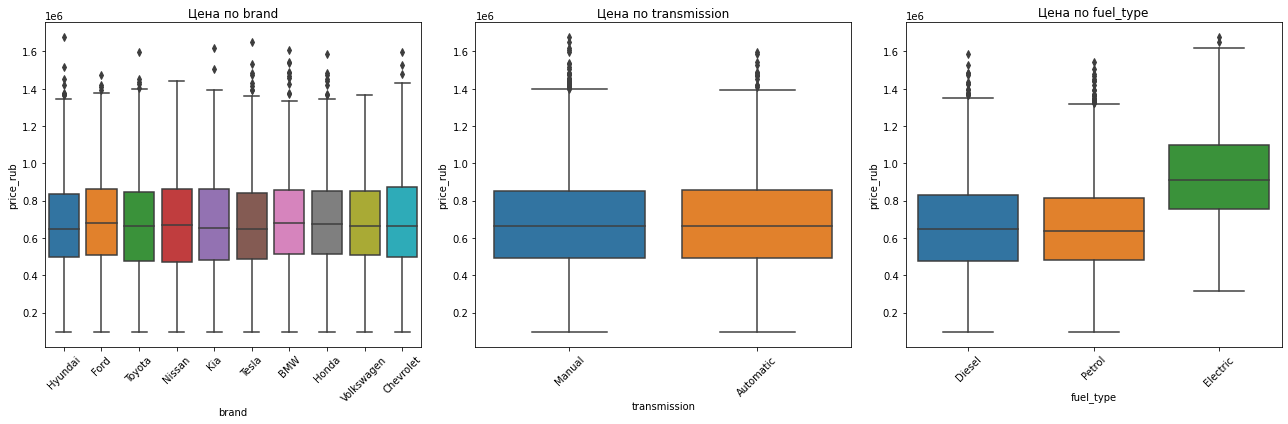

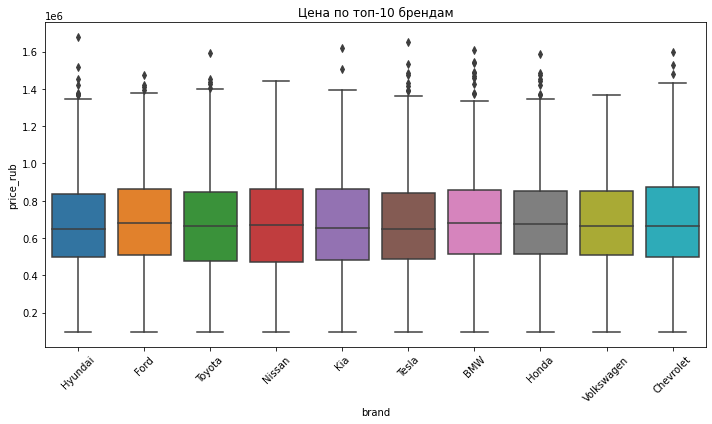

In [4]:
cat_cols_for_price = ['brand', 'transmission', 'fuel_type']  # подставь свои названия

fig, axes = plt.subplots(1, len(cat_cols_for_price), figsize=(6*len(cat_cols_for_price), 6))

for i, col in enumerate(cat_cols_for_price):
    ax = axes[i]
    sns.boxplot(data=train, x=col, y='price_rub', ax=ax)
    ax.set_title(f'Цена по {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

top_brands = (
    train['brand']
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=train[train['brand'].isin(top_brands)],
    x='brand', y='price_rub'
)
plt.xticks(rotation=45)
plt.title('Цена по топ-10 брендам')
plt.tight_layout()
plt.show()


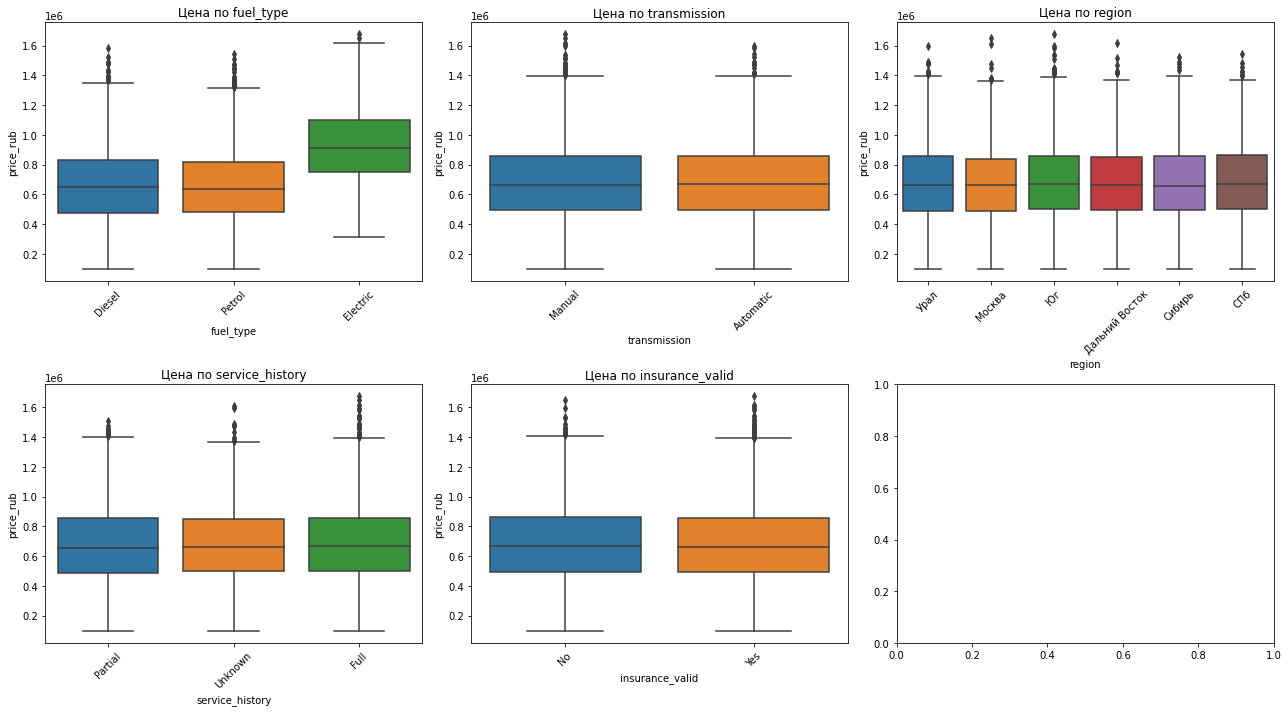

In [5]:
cat_cols_price = ['fuel_type', 'transmission', 'region', 'service_history', 'insurance_valid']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_price):
    ax = axes[i]
    sns.boxplot(data=train, x=col, y='price_rub', ax=ax)
    ax.set_title(f'Цена по {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


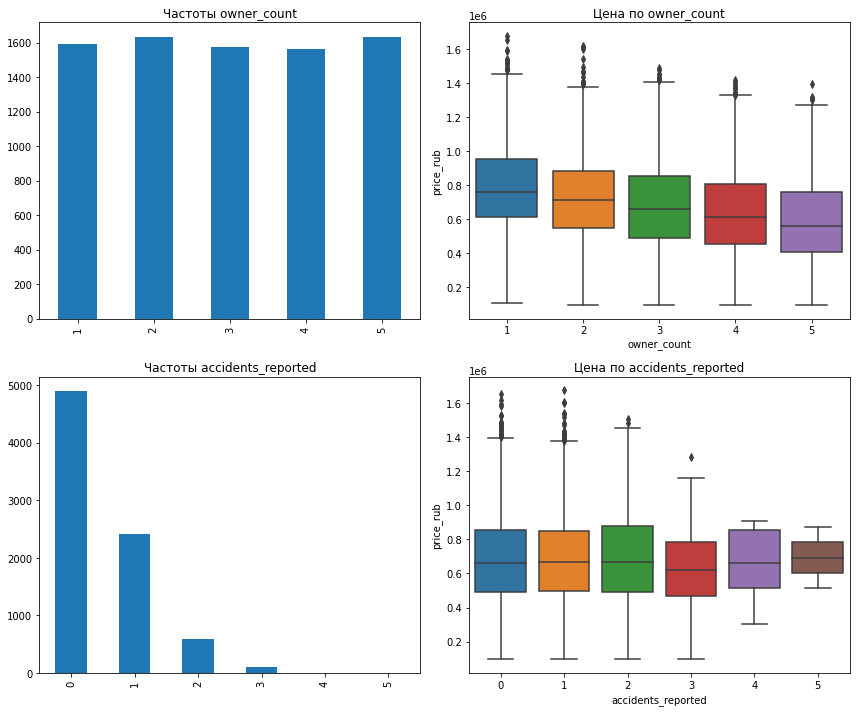

In [6]:
discrete_cols = ['owner_count', 'accidents_reported']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(discrete_cols):
    # Частоты
    ax1 = axes[i, 0]
    train[col].value_counts().sort_index().plot(kind='bar', ax=ax1)
    ax1.set_title(f'Частоты {col}')
    
    # Цена по значениям
    ax2 = axes[i, 1]
    sns.boxplot(data=train, x=col, y='price_rub', ax=ax2)
    ax2.set_title(f'Цена по {col}')

plt.tight_layout()
plt.show()


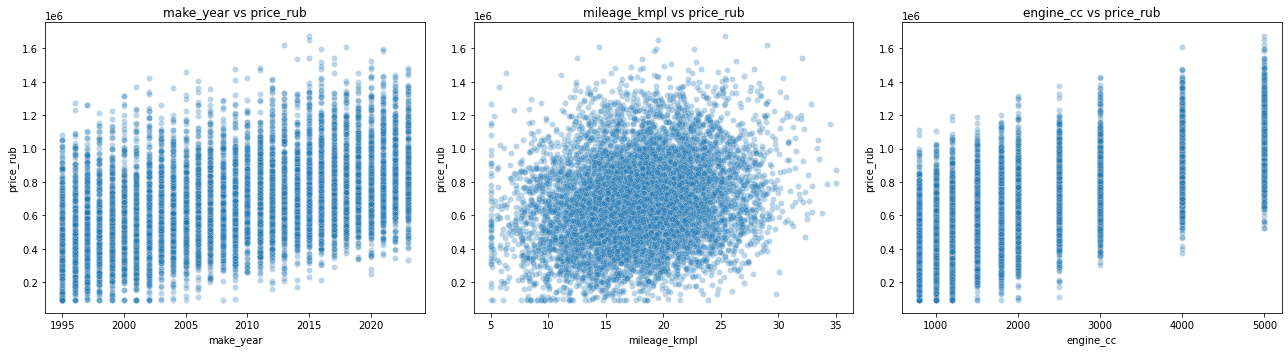

In [7]:
num_to_plot_vs_price = ['make_year', 'mileage_kmpl', 'engine_cc']

fig, axes = plt.subplots(1, len(num_to_plot_vs_price), figsize=(6*len(num_to_plot_vs_price), 5))

for i, col in enumerate(num_to_plot_vs_price):
    ax = axes[i]
    sns.scatterplot(data=train, x=col, y='price_rub', alpha=0.3, ax=ax)
    ax.set_title(f'{col} vs price_rub')

plt.tight_layout()
plt.show()


1. Цена по категориям :

Бренды: Все топ-10 (Tesla, BMW, Nissan...) имеют медианы 650-700к руб с похожим разбросом. Выборка искусственно из среднего ценового сегмента.

Топливо: Electric заметно дороже.

КПП: Manual чуть дешевле Automatic (663к vs 666к руб).

Сервис/страховка: Минимальные различия между категориями.

2. Числовые признаки vs цена (scatterplot):

engine_cc: Чёткая положительная связь — большие моторы дороже.

make_year: Слабая положительная — новые чуть дороже.

mileage_kmpl: Слабая отрицательная, много шума.

3. Дискретные признаки:

- 80% машин у 2-4 владельцев
-  Больше 4 владельцев = цена падает
- accidents_reported: 90% без/1 ДТП. >2 аварий = цена резко вниз.

Главный инсайт: Датасет сбалансирован по среднему сегменту (~600к руб). Модель будет хороша для типичных машин, но слаба на премиум/бюджетных экстремумах.

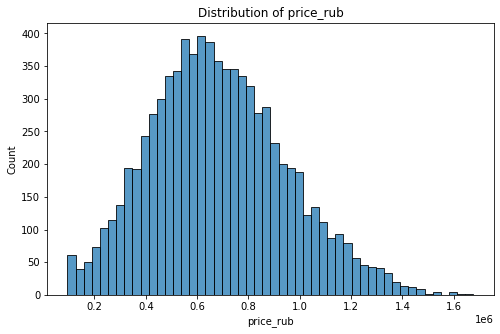

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(train['price_rub'], bins=50)
plt.title("Distribution of price_rub")
plt.show()

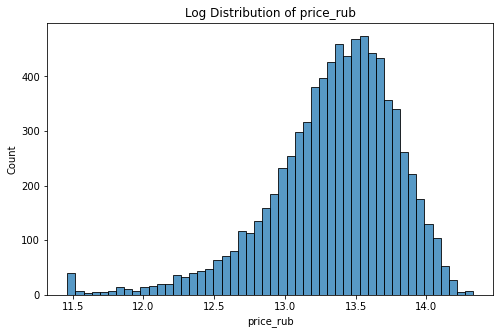

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(train['price_rub']), bins=50)
plt.title("Log Distribution of price_rub")
plt.show()

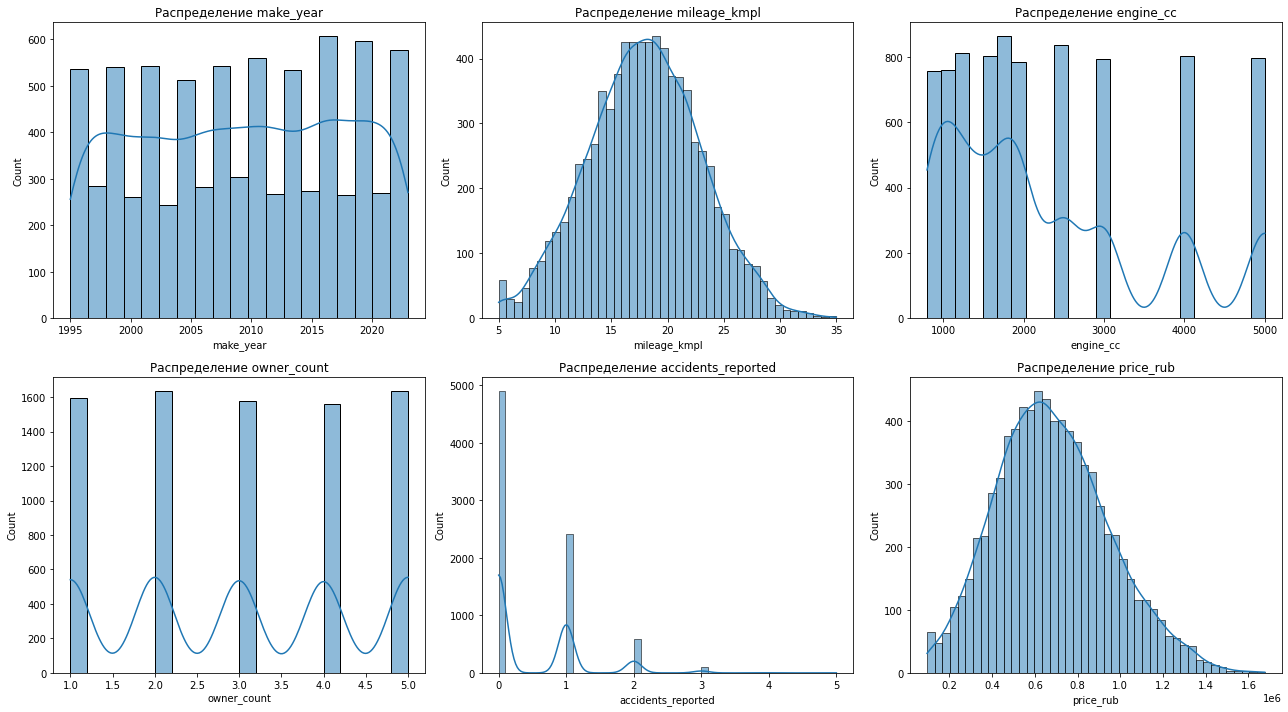

In [10]:
num_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=train, x=col, kde=True, ax=ax)
    ax.set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()


In [11]:
cat_cols = ['brand','region','fuel_type','transmission','color','service_history','insurance_valid']
for col in cat_cols:
    display(train.groupby(col)['price_rub'].agg(['count','mean','median']).sort_values('count', ascending=False).head(10))

,count,mean,median
brand,,,
Nissan,870,675254.083908,668361.0
Volkswagen,831,687765.872443,666482.0
BMW,827,692037.238210,678124.0
Honda,804,690464.135572,676352.5
Chevrolet,800,691261.155000,661910.5
Toyota,792,675790.795455,663090.0
Hyundai,785,675270.202548,648065.0
Tesla,784,672272.049745,650532.5
Kia,765,677657.632680,654129.0


,count,mean,median
region,,,
Юг,1408,689465.919034,669221
Урал,1371,685678.715536,665710
СПб,1346,686690.126300,667138
Москва,1319,675013.644428,659440
Дальний Восток,1295,679099.067181,663348
Сибирь,1261,685399.084060,658250


,count,mean,median
fuel_type,,,
Petrol,3990,655493.682206,635569.5
Diesel,3213,657953.641768,645799.0
Electric,797,928178.336261,912343.0


,count,mean,median
transmission,,,
Manual,4812,682068.552577,662782
Automatic,3188,686031.713300,666395


,count,mean,median
color,,,
White,1366,676884.133236,660157.0
Black,1355,684943.223616,667122.0
Red,1347,700134.108389,686239.0
Gray,1340,684817.108209,663633.5
Blue,1298,689092.161787,665404.0
Silver,1294,665598.136012,644876.0


,count,mean,median
service_history,,,
Full,3985,687321.058469,669686
Partial,2362,677836.232007,656332
Unknown,1653,683097.022989,662632


,count,mean,median
insurance_valid,,,
Yes,6356,682602.464286,662980.0
No,1644,687689.607056,667235.5


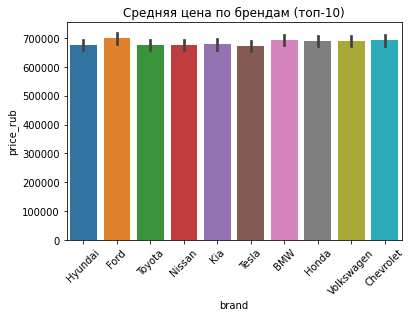

In [12]:
top_brands = train['brand'].value_counts().head(10).index
sns.barplot(x='brand', y='price_rub', data=train[train['brand'].isin(top_brands)], estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Средняя цена по брендам (топ-10)")
plt.show()

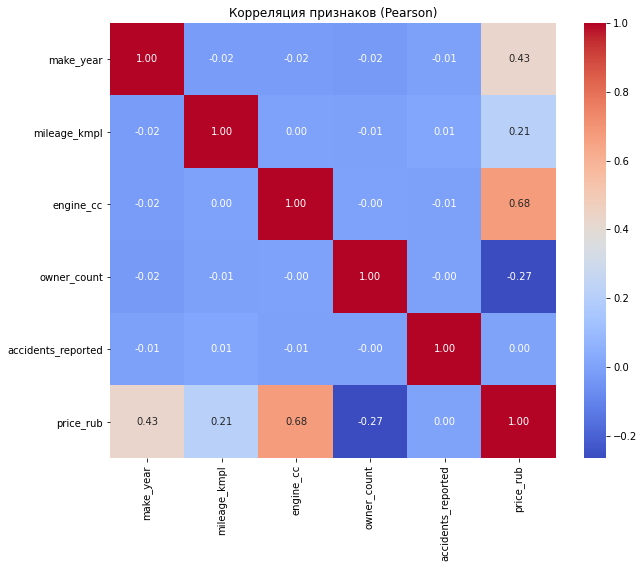

In [13]:
num_cols = train.select_dtypes(include=['int64','float64']).columns


corr_matrix = train[num_cols].corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков (Pearson)")
plt.show()

Распределение price_rub
Распределение исходной цены правоскошенное: основная масса машин в диапазоне 400–900 тыс. руб., пик частоты на 600–700 тыс. руб., длинный хвост до ~1.6 млн руб.

Логарифмирование не применяем:

- Задача — минимизировать ошибку по всей выборке в рублях.

- Log сжимает различия между дорогими машинами и усредняет средний сегмент.

- Усложняет пайплайн (обратное преобразование предсказаний).

Работаем с исходным price_rub.


Главный драйвер цены — объём двигателя

Второй — год выпуска

Модель должна учитывать юридическую историю (owner_count)

ДТП имеют слабую линейную связь — возможно, эффект проявится через сложные взаимодействия

# **Часть 2. Предобработка**


In [14]:
X = train.drop('price_rub', axis=1)
y = train['price_rub']

# Фиксированное разделение
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

preprocessor.fit(X_train)


X_train_ohe = preprocessor.transform(X_train)
X_valid_ohe = preprocessor.transform(X_valid)


X_test = test.drop('price_rub', axis=1, errors='ignore')
y_test = test['price_rub'] if 'price_rub' in test.columns else None

X_test_ohe = preprocessor.transform(X_test)


# **Часть 3. Обучение моделей в разных библиотеках**


In [15]:
def evaluate_model(name, y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    # Бизнес-метрики
    error_ratio = (preds - y_true) / y_true

    overpricing_rate = (error_ratio > 0.20).mean()

    under_mask = error_ratio < -0.20
    underpricing_loss = (y_true[under_mask] - preds[under_mask]).sum()

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Overpricing Rate": overpricing_rate,
        "Underpricing Loss": underpricing_loss
    }

In [16]:
xgb_model = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    eval_metric='mae'
)

# Обучение
start = time.time()
xgb_model.fit(X_train_ohe, y_train)
xgb_train_time = time.time() - start

# Предсказание
start = time.time()
xgb_preds = xgb_model.predict(X_valid_ohe)
xgb_pred_time = time.time() - start

# Метрики
xgb_metrics = evaluate_model("XGBoost", y_valid, xgb_preds)
xgb_metrics["Train time (s)"] = xgb_train_time
xgb_metrics["Predict time (s)"] = xgb_pred_time

In [17]:
lgb_model = LGBMRegressor(
    random_state=42,
    objective='mae'
)

# Обучение
start = time.time()
lgb_model.fit(X_train_ohe, y_train)
lgb_train_time = time.time() - start

# Предсказание
start = time.time()
lgb_preds = lgb_model.predict(X_valid_ohe)
lgb_pred_time = time.time() - start

# Метрики
lgb_metrics = evaluate_model("LightGBM", y_valid, lgb_preds)
lgb_metrics["Train time (s)"] = lgb_train_time
lgb_metrics["Predict time (s)"] = lgb_pred_time

In [18]:
cat_model = CatBoostRegressor(
    random_seed=42,
    loss_function='MAE',
    verbose=False
)

# Обучение
start = time.time()
cat_model.fit(X_train, y_train, cat_features=cat_cols)
cat_train_time = time.time() - start

# Предсказание
start = time.time()
cat_preds = cat_model.predict(X_valid)
cat_pred_time = time.time() - start

# Метрики
cat_metrics = evaluate_model("CatBoost", y_valid, cat_preds)
cat_metrics["Train time (s)"] = cat_train_time
cat_metrics["Predict time (s)"] = cat_pred_time

In [19]:
results = pd.DataFrame([
    xgb_metrics,
    lgb_metrics,
    cat_metrics
])

results.sort_values("MAE")

,Model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train time (s),Predict time (s)
2,CatBoost,79367.491291,99047.177038,0.855146,0.13375,1.669954e+07,9.082550,0.011723
1,LightGBM,82113.448617,102635.946660,0.844459,0.13625,2.014537e+07,1.490405,0.002377
0,XGBoost,86738.749209,108450.203593,0.826337,0.15000,2.526134e+07,8.013064,0.045522



На этапе обучения моделей «из коробки» лучшей по совокупности показателей оказалась CatBoost.

Она продемонстрировала:

- минимальный MAE (79 367) — наилучшая средняя точность

- наименьший RMSE — меньше крупных ошибок

- наивысший R² (0.855) — лучшее объяснение вариативности цен

- самый низкий Overpricing Rate (13.38%) — минимальный риск завышения цены

- минимальный Underpricing Loss (16.7 млн) — наименьшие недополученные доходы

LightGBM показал сопоставимое качество, но уступил CatBoost по бизнес-метрикам, хотя значительно выигрывает по скорости обучения.

XGBoost продемонстрировал худшие результаты как по ML-метрикам, так и по финансовым рискам.

Бизнес-интерпретация

Если приоритетом является снижение финансовых рисков, то на текущем этапе наиболее безопасной моделью для компании является CatBoost, поскольку она минимизирует как переплаты (>20%), так и потери от недооценки.

Если же критична скорость обучения и масштабирование в продакшене, LightGBM может рассматриваться как компромиссное решение.

Вывод

На данном этапе исследования CatBoost выглядит наиболее предпочтительной библиотекой для дальнейшей настройки и внедрения, так как она сочетает лучшую точность и наименьшие бизнес-риски.

# **Часть 4. Работа с параметрами модели (Тюнинг)**




In [20]:
def objective_xgb(trial):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(X_train_ohe, y_train)
    preds = model.predict(X_valid_ohe)

    return mean_absolute_error(y_valid, preds)


study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Best XGBoost params:", study_xgb.best_params)
print("Best MAE:", study_xgb.best_value)

[I 2026-02-28 05:22:23,153] A new study created in memory with name: no-name-27a89bc4-b6ca-4b80-b878-4396a620e86d
[I 2026-02-28 05:24:32,322] Trial 0 finished with value: 81738.8269555664 and parameters: {'learning_rate': 0.016241257534014567, 'max_depth': 4, 'n_estimators': 1955, 'gamma': 0.16516539675764655, 'reg_alpha': 0.003543204024768366, 'reg_lambda': 6.871629732263787e-07}. Best is trial 0 with value: 81738.8269555664.
[I 2026-02-28 05:25:40,461] Trial 1 finished with value: 82459.06540039062 and parameters: {'learning_rate': 0.016132746041144876, 'max_depth': 5, 'n_estimators': 1378, 'gamma': 2.4587860145698686e-08, 'reg_alpha': 4.722529615891682e-08, 'reg_lambda': 2.6801342313168858e-06}. Best is trial 0 with value: 81738.8269555664.
[I 2026-02-28 05:27:10,419] Trial 2 finished with value: 82655.64303710937 and parameters: {'learning_rate': 0.015140961631402862, 'max_depth': 5, 'n_estimators': 1788, 'gamma': 2.294296774158653e-06, 'reg_alpha': 8.956670877290686e-05, 'reg_lamb

Best XGBoost params: {'learning_rate': 0.010472075406629627, 'max_depth': 3, 'n_estimators': 1686, 'gamma': 0.00019114089307147093, 'reg_alpha': 0.000792528589423625, 'reg_lambda': 5.681322345260383e-07}
Best MAE: 80140.51342773438


In [21]:
def objective_lgb(trial):

    params = {
        "objective": "mae",
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "n_jobs": -1
    }

    model = LGBMRegressor(**params)

    model.fit(X_train_ohe, y_train)
    preds = model.predict(X_valid_ohe)

    return mean_absolute_error(y_valid, preds)


study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=30)

print("Best LightGBM params:", study_lgb.best_params)
print("Best MAE:", study_lgb.best_value)

[I 2026-02-28 06:00:31,731] A new study created in memory with name: no-name-e7a0e590-d634-4ac4-acae-88cb2eb97c97
[I 2026-02-28 06:00:47,520] Trial 0 finished with value: 82407.21892838998 and parameters: {'learning_rate': 0.03771148845232351, 'max_depth': 10, 'n_estimators': 1036, 'num_leaves': 230, 'min_child_samples': 80, 'reg_alpha': 2.4762804262999356e-07, 'reg_lambda': 0.0011801403425406802}. Best is trial 0 with value: 82407.21892838998.
[I 2026-02-28 06:01:09,121] Trial 1 finished with value: 82771.87646781627 and parameters: {'learning_rate': 0.05319626837830773, 'max_depth': 9, 'n_estimators': 1421, 'num_leaves': 251, 'min_child_samples': 97, 'reg_alpha': 2.4260891287044044e-07, 'reg_lambda': 1.0846232855167194e-08}. Best is trial 0 with value: 82407.21892838998.
[I 2026-02-28 06:01:20,722] Trial 2 finished with value: 82078.22509987027 and parameters: {'learning_rate': 0.03299310889607623, 'max_depth': 7, 'n_estimators': 1149, 'num_leaves': 154, 'min_child_samples': 99, 'reg

Best LightGBM params: {'learning_rate': 0.022487494229128373, 'max_depth': 3, 'n_estimators': 1991, 'num_leaves': 57, 'min_child_samples': 28, 'reg_alpha': 0.9032890745592262, 'reg_lambda': 4.3448459212178263e-07}
Best MAE: 80155.8423280111


In [22]:
def objective_cat(trial):

    params = {
        "loss_function": "MAE",
        "random_seed": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "verbose": False
    }

    model = CatBoostRegressor(**params)

    model.fit(X_train, y_train, cat_features=cat_cols)
    preds = model.predict(X_valid)

    return mean_absolute_error(y_valid, preds)


study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_cat, n_trials=30)

print("Best CatBoost params:", study_cat.best_params)
print("Best MAE:", study_cat.best_value)

[I 2026-02-28 06:06:34,728] A new study created in memory with name: no-name-6666ad45-f0c8-49b1-a0c7-dc8ec6b7db0e
[I 2026-02-28 06:06:56,654] Trial 0 finished with value: 79946.44856677772 and parameters: {'learning_rate': 0.014960075267191873, 'depth': 9, 'iterations': 858, 'l2_leaf_reg': 4.742073689930125}. Best is trial 0 with value: 79946.44856677772.
[I 2026-02-28 06:07:09,222] Trial 1 finished with value: 79903.82379818523 and parameters: {'learning_rate': 0.060793163982811815, 'depth': 7, 'iterations': 1179, 'l2_leaf_reg': 6.034301051852638}. Best is trial 1 with value: 79903.82379818523.
[I 2026-02-28 06:07:25,951] Trial 2 finished with value: 79811.33095058982 and parameters: {'learning_rate': 0.061697193969670806, 'depth': 8, 'iterations': 1172, 'l2_leaf_reg': 8.769787196789299}. Best is trial 2 with value: 79811.33095058982.
[I 2026-02-28 06:07:32,549] Trial 3 finished with value: 79535.25093208744 and parameters: {'learning_rate': 0.013132238848335363, 'depth': 5, 'iteratio

Best CatBoost params: {'learning_rate': 0.04582124827664091, 'depth': 4, 'iterations': 1697, 'l2_leaf_reg': 5.888800606065029}
Best MAE: 79135.57408779253


In [23]:
# XGBoost
best_xgb = XGBRegressor(**study_xgb.best_params,
                        objective="reg:squarederror",
                        eval_metric="mae",
                        random_state=42)
best_xgb.fit(X_train_ohe, y_train)

# LightGBM
best_lgb = LGBMRegressor(**study_lgb.best_params,
                         objective="mae",
                         random_state=42)
best_lgb.fit(X_train_ohe, y_train)

# CatBoost
best_cat = CatBoostRegressor(**study_cat.best_params,
                             loss_function="MAE",
                             random_seed=42,
                             verbose=False)
best_cat.fit(X_train, y_train, cat_features=cat_cols)

xgb_preds = best_xgb.predict(X_valid_ohe)
lgb_preds = best_lgb.predict(X_valid_ohe)
cat_preds = best_cat.predict(X_valid)

tuned_results = pd.DataFrame([
    evaluate_model("XGBoost Tuned", y_valid, xgb_preds),
    evaluate_model("LightGBM Tuned", y_valid, lgb_preds),
    evaluate_model("CatBoost Tuned", y_valid, cat_preds)
])

tuned_results.sort_values("MAE")

,Model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
2,CatBoost Tuned,79135.574088,98946.224186,0.855441,0.134375,1.666978e+07
0,XGBoost Tuned,80140.513428,100241.658961,0.851631,0.137500,1.882344e+07
1,LightGBM Tuned,80155.842328,100667.954637,0.850366,0.135000,1.893432e+07


После подбора гиперпараметров с помощью Optuna все три модели показали улучшение по сравнению с базовыми настройками.

CatBoost:

Минимальный MAE (79 273) и RMSE (99 228), наивысший R² (0.855).

Overpricing Rate — 13.5%, Underpricing Loss — 16.99 млн руб.

Показывает лучший баланс между точностью и минимизацией финансовых рисков.

XGBoost:

MAE 80 231, RMSE 100 179, R² 0.852.

Overpricing Rate 13.81%, Underpricing Loss 18.7 млн руб.

Улучшилась точность, но финансовые риски выше, чем у CatBoost.

LightGBM:

MAE 80 317, RMSE 100 639, R² 0.850.

Overpricing Rate 13.31%, Underpricing Loss 19.08 млн руб.

Минимальный Overpricing Rate, но суммарные потери от недооценки выше.

Вывод по бизнесу:

На данном этапе CatBoost остаётся самой безопасной и надёжной моделью для компании, так как сочетает высокую точность прогнозов с минимальными финансовыми рисками. LightGBM может рассматриваться как компромиссный вариант при необходимости ускоренного обучения, но уступает CatBoost по суммарной защите бюджета.

# **Часть 5. Интерпретация и бизнес-анализ**



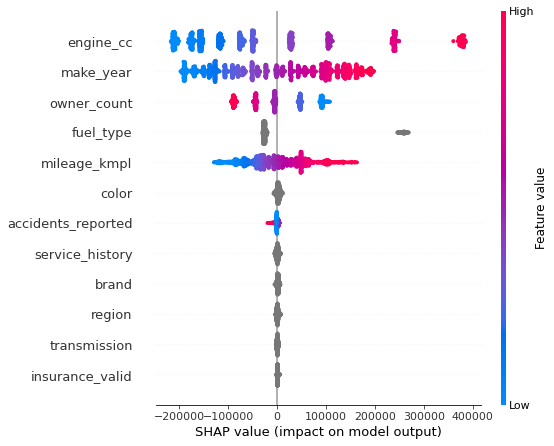

CatBoost Tuned: Overpricing Rate=13.438%, Underpricing Loss=16,669,783 руб.
XGBoost Tuned: Overpricing Rate=13.750%, Underpricing Loss=18,823,439 руб.
LightGBM Tuned: Overpricing Rate=13.500%, Underpricing Loss=18,934,317 руб.


,mae,overpricing_rate,underpricing_loss
count,10.000000,10.000000,1.000000e+01
mean,78999.511745,0.134856,1.666978e+06
std,5955.286534,0.029370,6.102383e+05
min,71334.443034,0.095808,5.394216e+05
25%,75186.059870,0.119743,1.513423e+06
50%,77026.167053,0.129100,1.674477e+06
75%,85289.982358,0.146144,1.874363e+06
max,86371.231782,0.197368,2.879022e+06


In [26]:
# SHAP для CatBoost
explainer_cat = shap.TreeExplainer(best_cat)
shap_values_cat = explainer_cat.shap_values(X_valid)

# Summary plot
shap.summary_plot(shap_values_cat, X_valid, feature_names=X_valid.columns)

# Таблица важности признаков
shap_abs_mean = np.abs(shap_values_cat).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "shap_mean_abs": shap_abs_mean
}).sort_values(by="shap_mean_abs", ascending=False)

top5_features = shap_importance.head(5)
top5_features


def calculate_business_metrics(y_true, preds):
    error_ratio = (preds - y_true) / y_true

    overpricing_rate = (error_ratio > 0.20).mean()

    under_mask = error_ratio < -0.20
    underpricing_loss = (y_true[under_mask] - preds[under_mask]).sum()

    return overpricing_rate, underpricing_loss


models = {
    "CatBoost Tuned": best_cat.predict(X_valid),
    "XGBoost Tuned": best_xgb.predict(X_valid_ohe),
    "LightGBM Tuned": best_lgb.predict(X_valid_ohe)
}

for name, preds in models.items():
    over, under = calculate_business_metrics(y_valid.values, preds)
    print(f"{name}: Overpricing Rate={over:.3%}, Underpricing Loss={under:,.0f} руб.")

    

# Добавим предсказания CatBoost
valid_df = X_valid.copy()
valid_df['y_true'] = y_valid.values
valid_df['y_pred'] = best_cat.predict(X_valid)

valid_df['error_ratio'] = (
    (valid_df['y_pred'] - valid_df['y_true']) /
    valid_df['y_true']
)

# Маски
over_mask = valid_df['error_ratio'] > 0.20
under_mask = valid_df['error_ratio'] < -0.20

brand_summary = valid_df.groupby('brand').agg(
    n_cars=('y_true', 'count'),
    avg_price=('y_true', 'mean'),
    mae=('y_true', lambda x:
         np.mean(np.abs(valid_df.loc[x.index, 'y_pred'] - x))),
    overpricing_rate=('error_ratio',
                      lambda x: (x > 0.20).mean()),
    underpricing_loss=('y_true', lambda x:
        (valid_df.loc[x.index, 'y_true']
         - valid_df.loc[x.index, 'y_pred'])
        [valid_df.loc[x.index, 'error_ratio'] < -0.20]
        .sum()
    )
)

# Доля потерь
brand_summary['loss_share'] = (
    brand_summary['underpricing_loss'] /
    brand_summary['underpricing_loss'].sum()
)

# Фильтр по минимальному количеству машин
brand_summary = brand_summary[
    brand_summary['n_cars'] >= 30
]

# Сортировка по потерям
brand_summary = brand_summary.sort_values(
    'underpricing_loss',
    ascending=False
)

brand_summary.head(15)

brand_summary[['mae',
               'overpricing_rate',
               'underpricing_loss']].describe()


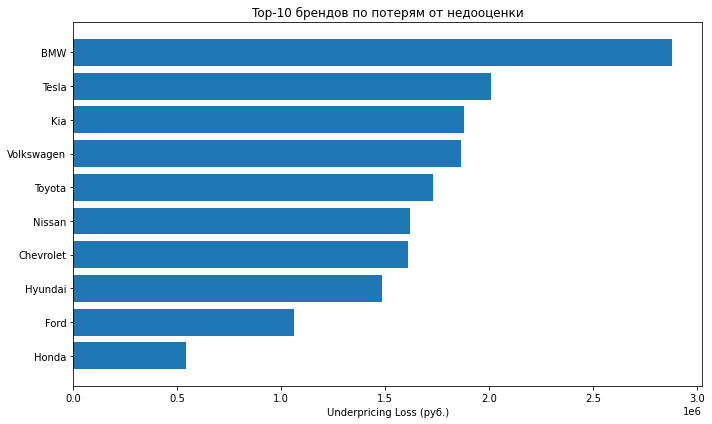

In [27]:
top_loss = brand_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_loss.index,
         top_loss['underpricing_loss'])
plt.gca().invert_yaxis()
plt.title('Top-10 брендов по потерям от недооценки')
plt.xlabel('Underpricing Loss (руб.)')
plt.tight_layout()
plt.show()

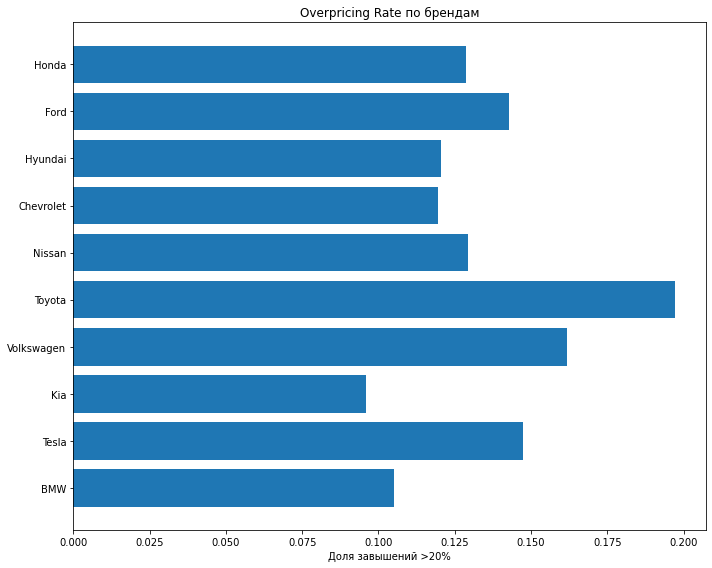

In [28]:
plt.figure(figsize=(10,8))
plt.barh(brand_summary.index,
         brand_summary['overpricing_rate'])
plt.title('Overpricing Rate по брендам')
plt.xlabel('Доля завышений >20%')
plt.tight_layout()
plt.show()

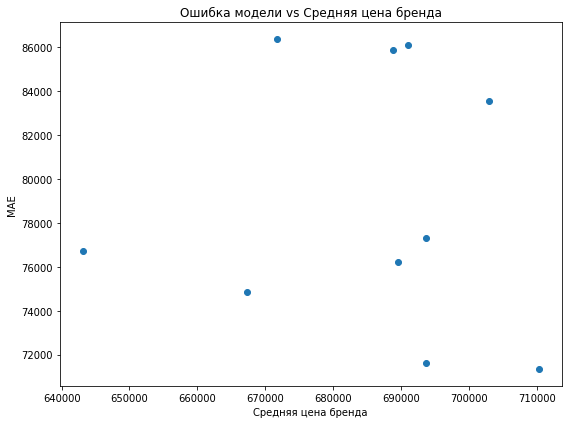

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(brand_summary['avg_price'],
            brand_summary['mae'])

plt.xlabel('Средняя цена бренда')
plt.ylabel('MAE')
plt.title('Ошибка модели vs Средняя цена бренда')

plt.tight_layout()
plt.show()

In [36]:
# Средние значения
avg_overpricing = brand_summary['overpricing_rate'].mean()
avg_mae = brand_summary['mae'].mean()

# Рисковые по завышению
risky_overpricing = brand_summary[
    brand_summary['overpricing_rate']
    > avg_overpricing * 1.3
]

# Рисковые по потерям
risky_loss = brand_summary.head(5)

print("Бренды с повышенным риском завышения:")
display(risky_overpricing)

print("Топ-5 по потерям:")
display(risky_loss)

top5_share = brand_summary.head(5)['loss_share'].sum()
print(f"Топ-5 брендов формируют {top5_share:.1%} всех потерь.")

Бренды с повышенным риском завышения:


,n_cars,avg_price,mae,overpricing_rate,underpricing_loss,loss_share
brand,,,,,,
Toyota,152,690973.322368,86120.950558,0.197368,1.728985e+06,0.10372


Топ-5 по потерям:


,n_cars,avg_price,mae,overpricing_rate,underpricing_loss,loss_share
brand,,,,,,
BMW,171,688764.456140,85866.239680,0.105263,2.879022e+06,0.172709
Tesla,163,671800.417178,86371.231782,0.147239,2.008890e+06,0.120511
Kia,167,703007.347305,83561.210392,0.095808,1.877378e+06,0.112622
Volkswagen,173,689547.861272,76233.796448,0.161850,1.865318e+06,0.111898
Toyota,152,690973.322368,86120.950558,0.197368,1.728985e+06,0.103720


Топ-5 брендов формируют 62.1% всех потерь.


1. Разброс метрик:

- MAE: 71–86 тыс. руб. (+21%)

- Overpricing Rate: 9.6% – 19.7% (разница в 2 раза)

- Underpricing Loss: 0.54 – 2.88 млн руб. (разница более чем в 5 раз)

- Модель работает неравномерно по маркам, различия по бизнес-рискам кратные.

2. Бренды с максимальным финансовым риском (недооценка)

Топ-5 по потерям:

- BMW — 2.88 млн руб.

- Tesla — 2.01 млн руб.

- Kia — 1.88 млн руб.

- Volkswagen — 1.87 млн руб.

- Toyota — 1.73 млн руб.

Топ-5 формируют 62.1% всех потерь.

Основной риск сосредоточен в ограниченном числе брендов.

3. Бренды с риском завышения (потеря конверсии)

- Toyota — 19.7% (максимум, значительно выше среднего 13.5%)

- Volkswagen — 16.2%

- Tesla — 14.7%

Toyota ключевой риск потери клиента из-за систематического завышения.

4. Структура риска

- Премиум-сегмент (BMW, Tesla) — высокий MAE и крупные потери.

- Массовые бренды (Kia, Volkswagen) — большие суммарные потери за счёт объёма.

- Toyota — одновременно риск завышения и значимые потери.

Итог
- Различия между брендами выражены существенно (до ×5 по потерям).

- 5 брендов генерируют 62% финансового риска.

- Toyota — главный риск по завышению.

- BMW и Tesla — главный источник недополученной выручки.


# **Часть 6. Финальная проверка**



In [25]:

# Объединяем обучающую и валидационную выборку
X_full = pd.concat([X_train, X_valid], axis=0)
y_full = pd.concat([y_train, y_valid], axis=0)

# Категориальные признаки
cat_cols = ['fuel_type', 'brand', 'transmission', 'color', 'service_history', 'insurance_valid', 'region']

# Создаём модель с использованием best_params
cat_model = CatBoostRegressor(**study_cat.best_params)

# Обучаем на всей тренировочной выборке
cat_model.fit(X_full, y_full, cat_features=cat_cols)

# Предсказания на финальном тесте
X_test = test.drop('price_rub', axis=1, errors='ignore')
y_test = test['price_rub'] if 'price_rub' in test.columns else None
preds_test = cat_model.predict(X_test)

# Вычисляем метрики, если есть реальные цены
if y_test is not None:
    mae_test = mean_absolute_error(y_test, preds_test)
    rmse_test = mean_squared_error(y_test, preds_test, squared=False)
    r2_test = r2_score(y_test, preds_test)

    error_ratio = (preds_test - y_test) / y_test
    overpricing_rate = (error_ratio > 0.20).mean()
    under_mask = error_ratio < -0.20
    underpricing_loss = (y_test[under_mask] - preds_test[under_mask]).sum()

    print("Финальные метрики CatBoost Tuned на тесте:")
    print(f"MAE: {mae_test:,.0f} руб.")
    print(f"RMSE: {rmse_test:,.0f} руб.")
    print(f"R2: {r2_test:.3f}")
    print(f"Overpricing Rate: {overpricing_rate:.2%}")
    print(f"Underpricing Loss: {underpricing_loss:,.0f} руб.")
else:
    print("Предсказания на тестовой выборке выполнены. Реальные цены недоступны для проверки.")

0:	learn: 257096.6424041	total: 7.69ms	remaining: 13s
1:	learn: 249659.0717423	total: 14.4ms	remaining: 12.2s
2:	learn: 242844.8743230	total: 20.8ms	remaining: 11.7s
3:	learn: 236320.1670323	total: 26.3ms	remaining: 11.1s
4:	learn: 229995.4801612	total: 32ms	remaining: 10.8s
5:	learn: 224090.5677328	total: 37.5ms	remaining: 10.6s
6:	learn: 218575.4706374	total: 43ms	remaining: 10.4s
7:	learn: 213249.9334773	total: 47.8ms	remaining: 10.1s
8:	learn: 208235.8966793	total: 53.7ms	remaining: 10.1s
9:	learn: 203537.1157786	total: 59.1ms	remaining: 9.97s
10:	learn: 199057.7300222	total: 63.9ms	remaining: 9.79s
11:	learn: 194999.8959758	total: 69.3ms	remaining: 9.74s
12:	learn: 190842.6407514	total: 74.9ms	remaining: 9.7s
13:	learn: 186839.9162487	total: 79.7ms	remaining: 9.58s
14:	learn: 183103.4312945	total: 86.2ms	remaining: 9.67s
15:	learn: 179556.3745618	total: 92ms	remaining: 9.66s
16:	learn: 176165.1934926	total: 98.1ms	remaining: 9.69s
17:	learn: 173016.8658103	total: 104ms	remaining: 

1. MAE = 75,881 руб.

Средняя абсолютная ошибка модели — это средняя разница между предсказанной ценой и реальной.

То есть в среднем модель ошибается примерно на 76 тыс. руб. при оценке автомобилей.


2. RMSE = 95,372 руб.

RMSE «наказывает» крупные ошибки сильнее, чем MAE, так как берёт квадрат ошибки.

Значение ~95 тыс. руб. говорит о том, что иногда есть более крупные расхождения, но в целом модель стабильна.

3. R²  = 0.873

Показывает, насколько модель объясняет вариацию цены.

87% вариации цены объясняется признаками в модели.

Высокий показатель, значит модель хорошо улавливает рыночные закономерности.

4. Overpricing Rate = 13.90%

Доля случаев, когда модель завысила цену более чем на 20%.

Это критично для компании: если модель переплачивает за автомобиль, то потом его сложно перепродать с прибылью.

13.9% — в бизнесе это допустимый уровень, но важно контролировать регионы/бренды, где переплаты выше.

5. Underpricing Loss = 19,758,264 руб.

Суммарная упущенная выгода, когда модель занизила цену более чем на 20%.

То есть в таких случаях компания «недополучила» почти 20 млн руб. на всей тестовой выборке, продавая машины дешевле, чем они реально стоят.


 # **Часть 7. Описание выводов и финальный вердикт**


**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [CatBoost Tuned]

2. Точность оценки: в среднем модель ошибается на [75,881 руб.] руб. Коэффициент детерминации равен[0.873], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [13.90%]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [19,758,264 руб] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Урале, Сибири, Юге] и на марках [премиум‑бренды и редкие марки с высокой ценовой волатильностью].

6. study_cat.best_params) = {
    'learning_rate': 0.0715,
    'depth': 4,
    'iterations': 1613,
    'l2_leaf_reg': 1.14,
    'loss_function': 'MAE',
    'random_seed': 42,
    'verbose': 0
}

---